## Import dan konfigurasi 

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

START_DATE = "2025-12-01 00:00:00"
END_DATE   = "2026-05-31 23:00:00"
FREQ       = "1h"

TEMP_CFG = {
    'peak_mean': 29.3, 
    'trough_mean': 24.1,
    'noise_std': 0.9,
    'min': 21.5,
    'max': 31.9,
    'peak_hour': 13,
    'trough_hour': 4
}

HUM_CFG = {
    'peak_mean': 85.0, 
    'trough_mean': 84.8,
    'noise_std': 2.2,
    'min': 80.3,
    'max': 85.0,
    'peak_hour': 4,
    'trough_hour': 13
}

SOIL_CFG = {
    'initial': 58.0,
    'pump_boost': 8.0,
    'decay_day': 0.55,
    'decay_night': 0.20,
    'noise_std': 0.30,
    'min': 10.0,
    'max': 92.0
}

PUMP_CFG = {
    'schedule_hours': [6, 12, 15],  
    'duration_hours': 1
}


EC_CFG = {
    'val_veg': 1.6,
    'val_gen': 2.0,
    # 'cutoff_date': "2026-01-31 23:59:59"
    'max_veg_day': 35
}

N_CFG = {
    'mean': 165.0,
    'ar_coef': 0.96,
    'noise_std': 1.80,
    'min_val': 80.0,
    'max_val': 240.0
}

P_CFG = {
    'mean': 62.0,
    'ar_coef': 0.97,
    'noise_std': 0.90,
    'min_val': 20.0,
    'max_val': 110.0
}

K_CFG = {
    'mean': 235.0,
    'ar_coef': 0.95,
    'noise_std': 2.50,
    'min_val': 100.0,
    'max_val': 360.0
}

## Helper buat fisika dan agrikultur

In [27]:
def asimetris_daily(timestamps, peak_mean, trough_mean, noise_std, peak_hour, trough_hour, **kwargs):
    """
    Pola suhu/kelembapan harian asimetris.
    Naik cepat dari trough ke peak, turun lambat kembali ke trough.
    """
    hours = np.array(timestamps.hour + timestamps.minute / 60.0)
    
    if peak_hour >= trough_hour:
        delta_rise = peak_hour - trough_hour
    else:
        delta_rise = (peak_hour + 24) - trough_hour
    delta_fall = 24.0 - delta_rise
    
    amplitude = (peak_mean - trough_mean) / 2.0
    base = (peak_mean + trough_mean) / 2.0
    
    hours_shifted = (hours - trough_hour) % 24.0
    
    mask_rise = hours_shifted < delta_rise
    mask_fall = ~mask_rise
    
    result = np.empty_like(hours)
    result[mask_rise] = base - amplitude * np.cos(np.pi * hours_shifted[mask_rise] / delta_rise)
    t_fall = hours_shifted[mask_fall] - delta_rise
    result[mask_fall] = base + amplitude * np.cos(np.pi * t_fall / delta_fall)
    
    result += np.random.normal(0, noise_std, len(timestamps))
    return result

def generate_ar1(n, mean, ar_coef, noise_std, min_val, max_val, **kwargs):
    """Simulasi NPK dan EC menggunakan AR(1) yang smooth."""
    series = np.zeros(n)
    series[0] = np.clip(np.random.normal(mean, noise_std), min_val, max_val)
    for t in range(1, n):
        series[t] = (ar_coef * series[t - 1] + 
                     (1.0 - ar_coef) * mean + 
                     np.random.normal(0, noise_std))
    return np.clip(series, min_val, max_val)

def simulate_soil_and_pump_scheduled(n, timestamps, temp_arr, soil_cfg, pump_cfg):
    """
    Simulasi kelembapan tanah dengan pompa menyala sesuai jadwal tetap.
    """
    soil = np.zeros(n)
    pump = np.zeros(n, dtype=int)
    soil[0] = soil_cfg['initial']
    
    schedule = pump_cfg['schedule_hours']
    duration = pump_cfg['duration_hours']
    
    for t in range(1, n):
        hour = timestamps[t].hour
        prev_sm = soil[t-1]
        
        # Evaporasi adaptif
        temp_factor = 1.0 + max(0.0, (temp_arr[t] - 22.0) * 0.012)
        decay = (soil_cfg['decay_day'] if 8 <= hour <= 18 else soil_cfg['decay_night']) * temp_factor
        
        # Cek jadwal penyiraman
        is_watering = False
        for start_h in schedule:
            if start_h <= hour < start_h + duration:
                is_watering = True
                break
        pump[t] = 1 if is_watering else 0
        
        noise = np.random.normal(0, soil_cfg['noise_std'])
        if pump[t] == 1:
            soil[t] = prev_sm + soil_cfg['pump_boost'] - decay + noise
        else:
            soil[t] = prev_sm - decay + noise
        
        soil[t] = np.clip(soil[t], soil_cfg['min'], soil_cfg['max'])
    
    return soil, pump

## eksekusi data dan generate

In [28]:
print("Membuat dataset...")
timestamps = pd.date_range(start=START_DATE, end=END_DATE, freq=FREQ)
n = len(timestamps)

suhu = np.clip(
    asimetris_daily(timestamps, **TEMP_CFG),
    TEMP_CFG['min'], TEMP_CFG['max']
)
kelembapan = np.clip(
    asimetris_daily(timestamps, **HUM_CFG),
    HUM_CFG['min'], HUM_CFG['max']
)

tanah, pompa = simulate_soil_and_pump_scheduled(n, timestamps, suhu, SOIL_CFG, PUMP_CFG)

cutoff = pd.Timestamp(START_DATE) + pd.Timedelta(days=EC_CFG['max_veg_day'])
ec = np.where(timestamps <= cutoff, EC_CFG['val_veg'], EC_CFG['val_gen'])

fase = np.where(timestamps <= cutoff, 0, 1)

nitrogen = generate_ar1(n, **N_CFG)
fosfor = generate_ar1(n, **P_CFG)
kalium = generate_ar1(n, **K_CFG)

df = pd.DataFrame({
    'Timestamp': timestamps,
    'Suhu_Udara': np.round(suhu, 2),
    'Kelembapan_Udara': np.round(kelembapan, 2),
    'Kelembapan_Tanah': np.round(tanah, 2),
    'EC_Tangki': np.round(ec, 3),
    'N': np.round(nitrogen, 2),
    'P': np.round(fosfor, 2),
    'K': np.round(kalium, 2),
    'Status_Pompa': pompa,
    'Fase': fase
}).set_index('Timestamp')

df.to_csv("dataset/dataset_paprika_batu_scheduled.csv")
print("Dataset berhasil disimpan ke CSV.")

Membuat dataset...
Dataset berhasil disimpan ke CSV.


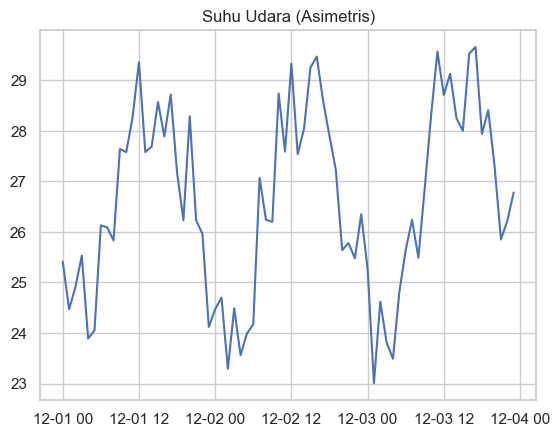

In [29]:
import matplotlib.pyplot as plt
sampel = df.iloc[:72]  # 3 hari pertama
plt.plot(sampel.index, sampel['Suhu_Udara'])
plt.title('Suhu Udara (Asimetris)')
plt.show()

## visualisasi

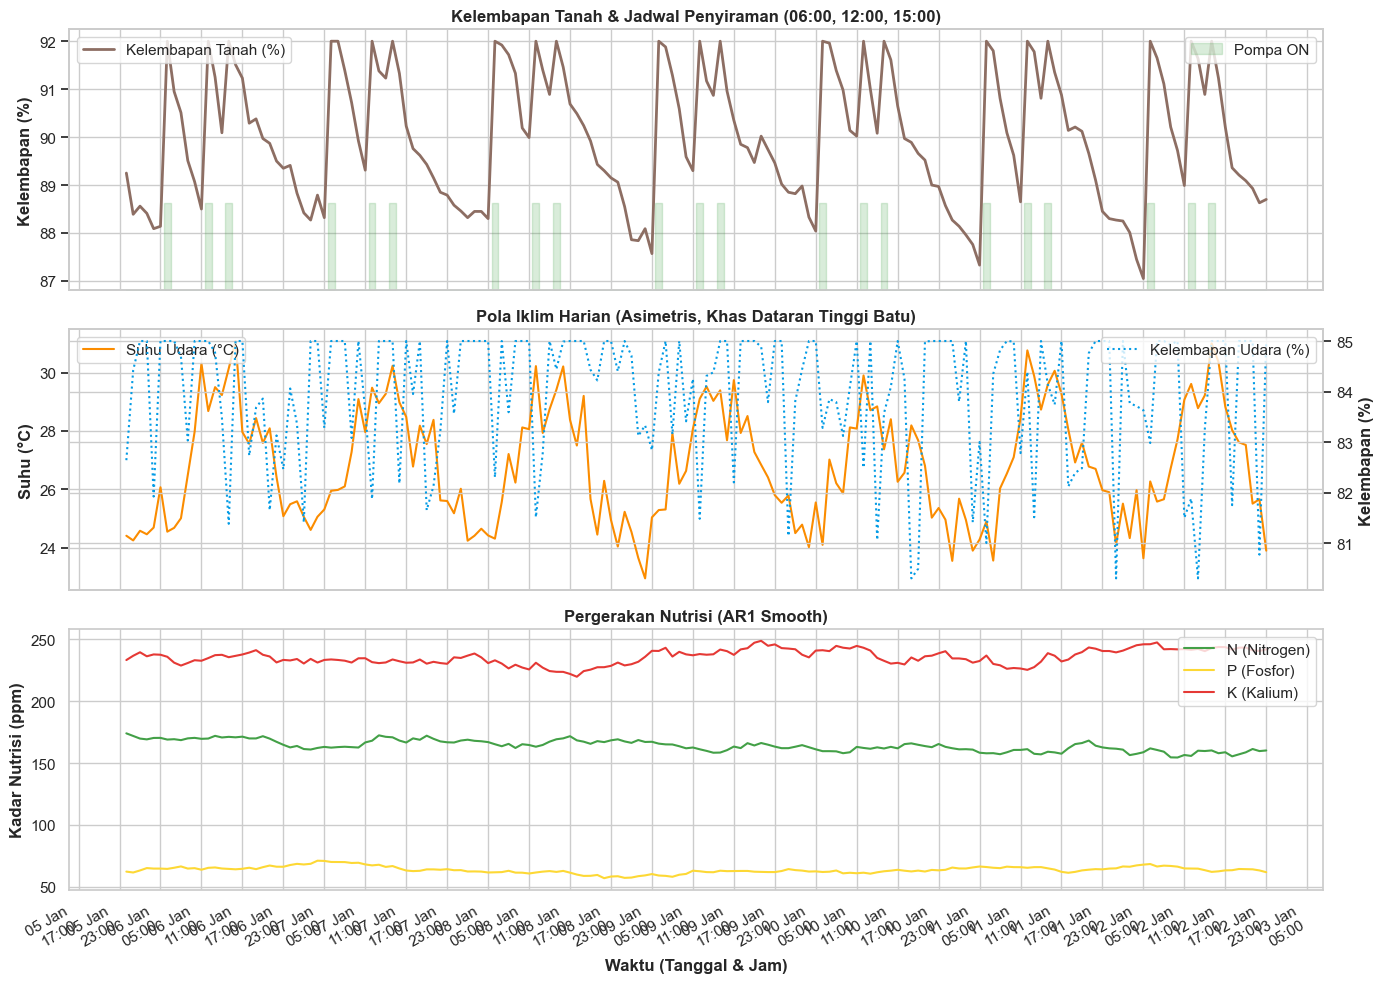

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# ── Konfigurasi tampilan (ganti sesuai kebutuhan) ──
VIS_START = "2026-01-06"
VIS_END   = "2026-01-12"
INTERVAL_JAM = 6          # ticks setiap berapa jam
ROTASI = 30               # rotasi label tanggal

# Filter data
df_vis = df[VIS_START:VIS_END]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# ── 1. Kelembapan Tanah & Status Pompa ──
ax1 = axes[0]
ax1.plot(df_vis.index, df_vis['Kelembapan_Tanah'], color='#8D6E63', lw=2, label='Kelembapan Tanah (%)')
ax1.set_ylabel("Kelembapan (%)", fontweight='bold')

# Area hijau saat pompa menyala
ax1r = ax1.twinx()
ax1r.fill_between(df_vis.index, df_vis['Status_Pompa'], color='#43A047', alpha=0.2, step='mid', label='Pompa ON')
ax1r.set_ylim(0, 3)
ax1r.set_yticks([])

ax1.set_title("Kelembapan Tanah & Jadwal Penyiraman (06:00, 12:00, 15:00)", fontweight='bold')
ax1.legend(loc='upper left')
ax1r.legend(loc='upper right')

# ── 2. Suhu & Kelembapan Udara ──
ax2 = axes[1]
ax2.plot(df_vis.index, df_vis['Suhu_Udara'], color='#FB8C00', label='Suhu Udara (°C)')
ax2.set_ylabel("Suhu (°C)", fontweight='bold')

ax2r = ax2.twinx()
ax2r.plot(df_vis.index, df_vis['Kelembapan_Udara'], color='#039BE5', ls=':', label='Kelembapan Udara (%)')
ax2r.set_ylabel("Kelembapan (%)", fontweight='bold')

ax2.set_title("Pola Iklim Harian (Asimetris, Khas Dataran Tinggi Batu)", fontweight='bold')
ax2.legend(loc='upper left')
ax2r.legend(loc='upper right')

# ── 3. Nutrisi NPK ──
ax3 = axes[2]
ax3.plot(df_vis.index, df_vis['N'], color='#43A047', label='N (Nitrogen)')
ax3.plot(df_vis.index, df_vis['P'], color='#FDD835', label='P (Fosfor)')
ax3.plot(df_vis.index, df_vis['K'], color='#E53935', label='K (Kalium)')
ax3.set_title("Pergerakan Nutrisi (AR1 Smooth)", fontweight='bold')
ax3.set_ylabel("Kadar Nutrisi (ppm)", fontweight='bold')
ax3.legend(loc='upper right')

# ── Format sumbu X ──
ax3.set_xlabel("Waktu (Tanggal & Jam)", fontweight='bold', fontsize=12)
ax3.xaxis.set_major_locator(mdates.HourLocator(interval=INTERVAL_JAM))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%H:%M'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=ROTASI, ha='right')

plt.tight_layout()
plt.show()